In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.style.use('ggplot')
%matplotlib inline
import pandas as pd
import numpy as np
import json
from sklearn.metrics import roc_auc_score
import logging

logging.basicConfig(level=logging.INFO)

## Sentences in a single article

In [17]:
from src.HC_survival_function import get_HC_survival_function
from scipy.interpolate import RectBivariateSpline
from src.fit_survival_function import fit_survival_func

HC_pval_func = get_HC_survival_function(gamma=0.45, stbl='stbl',
HC_null_sim_file_prefix="HC_null_sim_results")
    

INFO:root:HC null values file: HC_null_sim_results_743fa5e931.csv
INFO:root:Loading HC null values from HC_null_sim_results_743fa5e931.csv...


In [63]:
df = pd.read_csv("HC_null_sim_results_743fa5e931.csv", index_col=0)
df.shape

(10000, 11)

In [69]:
HC_null_sim_file = "HC_null_sim_results_743fa5e931.csv"
df = pd.read_csv(HC_null_sim_file, index_col=0)
xx = {}
nMonte = 10000
for n in df.columns:
    xx[n] = df.loc[:,n].values
    assert len(xx[n]) == nMonte, f"n={n} has {len(xx[n])} values."

In [15]:
np.mean(df['75'] > 5)

0.0

In [25]:
nn = NN = [25, 50, 75, 100, 125, 150, 200, 250, 300, 400, 500]
log_space = True

xx = {}
for n in df.index:
    xx[n] = df.loc[n]

xx0 = np.linspace(-1, 8, 57)
zz = []
for n in nn:
    univariate_survival_func = fit_survival_func(xx[n], log_space=True)
    zz.append(univariate_survival_func(xx0))
    
func_log = RectBivariateSpline(np.array(nn), xx0, np.vstack(zz))

In [ ]:
df = pd.read_csv(HC_null_sim_file, index_col=0)
df.

In [62]:
df.loc[:,str(n)]

0       0.693332
1       0.488794
2       1.308296
3      -0.255014
4       1.348861
          ...   
9995    1.699784
9996    1.761572
9997    1.980673
9998    0.258466
9999    1.006851
Name: 500, Length: 10000, dtype: float64

In [56]:
xx[n]

AttributeError: 'dict' object has no attribute 'loc'

In [51]:
1 / (len(xx[n] + 1)

0.07692307692307693

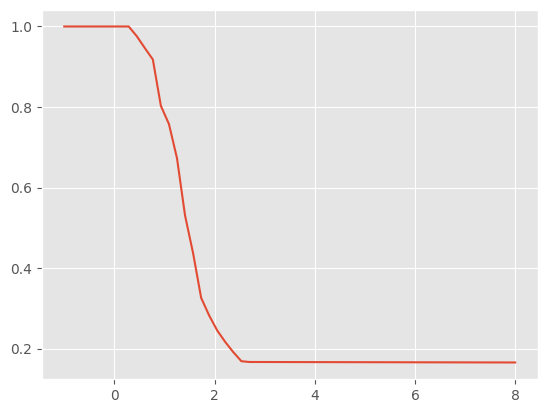

In [45]:
plt.plot(xx0, np.exp(-univariate_survival_func(xx0)))

In [42]:
np.exp(-func_log(78, 9))

array([[0.15777918]])

In [6]:
file_name = "results/evaluations_bio_edited_phi2.json"

# read json file:
with open(file_name, 'r') as f:
    data = json.load(f)


In [53]:
i = 0
title= list(data[0].keys())[0]
sentences = data[0][title]['sentences']
responses = [sentences[k]['response'] for k in range(len(sentences))]
pvalues = [sentences[k]['pvalue'] for k in range(len(sentences))]
texts = [sentences[k]['sentence'] for k in range(len(sentences))]
lengths = [len(texts[k].split()) for k in range(len(texts))]
tags = [sentences[k]['tag'] for k in range(len(sentences))]
mask = [sentences[k]['mask'] for k in range(len(sentences))]

df_doc1 = pd.DataFrame({'sentence':texts, 'response':responses, 'pvalue':pvalues, 'len':lengths, 'tag':tags, 'mask':mask})

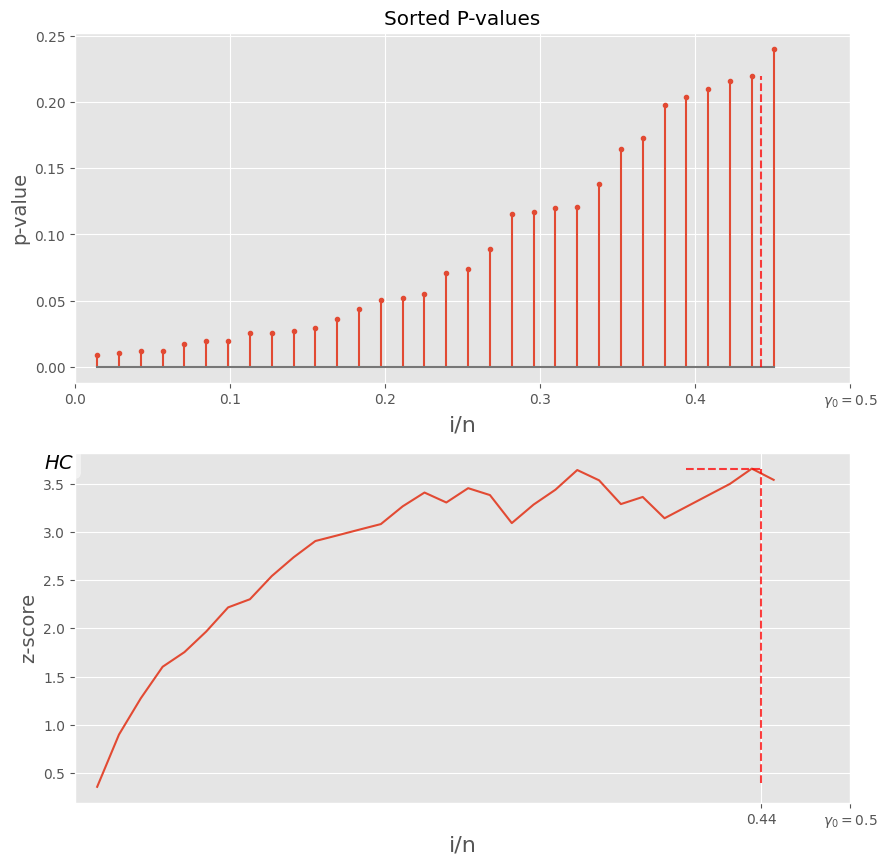

(3.6546365242850496, 0.22)


/var/folders/3n/c1thdb3136qc3c_4t5br9r6c0000gq/T/ipykernel_24772/2087511889.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_disp[~df_disp.pvalue.isna()].sort_values('pvalue')[df_disp['mask']]


,sentence,response,pvalue,len,tag,mask
33,\textcolor{blue}\textcolor{blue}His belief was...,3.741,0.0092,27,<edit>,True
23,\textcolor{blue}\textcolor{blue}With this cycl...,3.953,0.0105,28,<edit>,True
34,\textcolor{blue}\textcolor{blue}His anti-Chris...,4.220,0.0117,21,<edit>,True
70,"The ethical dimensions of Camus's work,......",3.783,0.0123,24,no edits,True
45,"Departing from the existentialist tradition, h...",3.947,0.0169,19,no edits,True
43,\textcolor{blue}\textcolor{blue}To distinguish...,4.008,0.0192,18,<edit>,True
22,\textcolor{blue}\textcolor{blue}The first was ...,4.954,0.0197,17,<edit>,True
46,This nuanced perspective positioned Camus as.....,4.191,0.0258,16,no edits,True
28,His philosophical divergence became evident in...,3.492,0.0258,34,no edits,True
47,In addition to his philosophical contributions...,3.415,0.0272,24,no edits,True


In [57]:
MIN_LEN = 7
df_doc1 = df_doc1[df_doc1.len >= MIN_LEN]

df_disp = df_doc1
df_disp.loc[:, 'response'] = df_disp['response'].apply(lambda x : np.round(x,3))
df_disp.loc[:, 'pvalue'] = df_disp['pvalue'].apply(lambda x : np.round(x,4))
df_disp.loc[df_disp.tag == '<edit>', 'sentence'] = '\\textcolor{blue}' + df_disp.loc[df_disp.tag == '<edit>', 'sentence']

df_disp['sentence'] = df_disp['sentence'].apply(lambda x : " ".join(x.split()[:6]) + "...")


a = df_disp.filter(['sentence', 'response', 'pvalue'])
b = df_disp[df_disp['mask']].filter(['sentence', 'pvalue']).sort_values('pvalue')

from multitest import MultiTest
pvals = df_disp['pvalue']
mt = MultiTest(pvals[~np.isnan(pvals)], stbl=True)
mt.hc_dashboard(gamma=0.45)
print(mt.hc(gamma=0.45))

df_disp[~df_disp.pvalue.isna()].sort_values('pvalue')[df_disp['mask']]

In [58]:

df_disp

,sentence,response,pvalue,len,tag,mask
2,Albert Camus (1913–1960) was a French......,2.579,0.6387,19,no edits,False
3,"Born on November 7, 1913, in......",2.842,0.3858,23,no edits,False
4,"His father, Lucien Camus, was a......",2.675,0.5385,19,no edits,False
5,This early loss profoundly influenced his......,4.072,0.0710,13,no edits,False
6,Growing up in poverty with his......,3.178,0.2775,22,no edits,False
...,...,...,...,...,...,...
70,"The ethical dimensions of Camus's work,......",3.783,0.0123,24,no edits,True
71,His insistence on the primacy of......,3.227,0.1200,27,no edits,False
72,Camus's legacy extends beyond academia into......,2.188,0.9000,20,no edits,False
73,"His ideas, often distilled into memorable......",3.011,0.2403,23,no edits,False


## Pre-computed logloss per sentence

In [85]:
df = pd.read_csv('~/downloads/historical_figures_sentences.csv', encoding='latin1')

In [170]:
res = {}
labels = []
for c in df.groupby(['article_number', 'model', 'fold_number']):
    pvals = c[1]['pvalue']
    mt = MultiTest(pvals[~np.isnan(pvals)], stbl=False)
    minp = mt.minp()
    hc,_ = mt.hc(gamma=0.15)
    fisher,_ = mt.fisher()
    edit_ratio = np.mean(c[1]['edited_sentence']>0)
    res[c[0]] = {'minP':minp, 'hc':hc, 'fisher':fisher, 'edit_ratio':edit_ratio}
    labels.append(edit_ratio>0)

df_res = pd.DataFrame(res).T
df_res['label'] = labels
df_res.groupby('label').agg(['mean', 'std'])

# find AUC-ROC for each statistic:
roc_auc_score(df_res['label'], df_res['minP']), roc_auc_score(df_res['label'], df_res['hc']), roc_auc_score(df_res['label'], df_res['fisher'])

/Users/kipnisal/Dropbox/Research/AuthorshipAI/env/lib/python3.10/site-packages/multitest/MultiTest.py:58: RuntimeWarning: invalid value encountered in sqrt
  if stbl:


(0.8019218749999999, 0.8045125000000002, 0.6709625000000001)

article_0_sentences_edited    gpt2xl  0    0.131944
                                      1    0.129213
                                      2    0.129032
                                      3    0.133971
                                      4    0.120000
                                             ...   
article_9_sentences_original  phi2    5    0.000000
                                      6    0.000000
                                      7    0.000000
                                      8    0.000000
                                      9    0.000000
Name: edit_ratio, Length: 800, dtype: float64

In [132]:
edf_res = pd.DataFrame(res).T
df_res['label'] = labels
df_res.groupby('label').agg(['mean', 'std'])

# find AUC-ROC for each statistic:
roc_auc_score(df_res['label'], df_res['minP']), roc_auc_score(df_res['label'], df_res['hc']), roc_auc_score(df_res['label'], df_res['fisher'])

(0.8019218749999999, 0.7588875, 0.6709625000000001)